In [85]:
# 1. 数据基础库
%pip install numpy pandas

# 2. 可视化库
%pip install matplotlib seaborn

# 3. 机器学习库
%pip install scikit-learn

# 4. 统计分析库
%pip install statsmodels scipy

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'd:\modeling\.venv\Scripts\python.exe -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'd:\modeling\.venv\Scripts\python.exe -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'd:\modeling\.venv\Scripts\python.exe -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'd:\modeling\.venv\Scripts\python.exe -m pip install --upgrade pip' command.


In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# 统计分析库
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

# 机器学习库
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 设置中文显示和图形样式
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

In [87]:
print("=" * 60)
print("         时间序列预测ARIMA模型 - 股票价格预测案例")
print("=" * 60)

         时间序列预测ARIMA模型 - 股票价格预测案例


第一步：数据生成与加载

In [88]:
def generate_stock_data(start_date='2025-01-01', periods=100,initial_price=100):
    """
    生成模拟股票价格数据
    包含趋势、波动率和随机游走特征
    """
    np.random.seed(42)  # 保证结果可复现

    # 创建日期索引
    dates = pd.date_range(start=start_date, periods=periods, freq='D')

    # 生成价格序列：随机游走+微弱趋势+波动率变化
    returns = np.random.normal(0.001, 0.02,periods)  #日收益率
    trend = np.linspace(0,0.5,periods)/periods  #微弱上升趋势
    volatility = 1 + 0.3 * np.sin(np.linspace(0, 4*np.pi, periods))  #波动率周期变化

    returns = returns + trend
    returns = returns * volatility

    # 计算累积价格
    prices = [initial_price]
    for r in returns[1:]:
        prices.append(prices[-1] * (1+r))

    # 创建dataframe
    df = pd.DataFrame({
        'date':dates,
        'price':prices,
        'returns':[0] + list(np.diff(np.log(prices)))  # 对数收益率
    })
    df.set_index('date',inplace=True)

    return df


# 生成数据
print("\n1.数据生成与加载")
print('-'*30)
stock_data = generate_stock_data()
print(f"数据区间：{stock_data.index[0].strftime('%Y-%m-%d')}至{stock_data.index[-1].strftime('%Y-%m-%d')}")
print(f"数据点数: {len(stock_data)}")
print(f"价格范围: {stock_data['price'].min():.2f} - {stock_data['price'].max():.2f}")

# 显示基本统计信息
print("\n数据基本统计:")
print(stock_data.describe())


1.数据生成与加载
------------------------------
数据区间：2025-01-01至2025-04-10
数据点数: 100
价格范围: 86.55 - 112.91

数据基本统计:
            price     returns
count  100.000000  100.000000
mean    99.156003    0.001201
std      8.420793    0.018911
min     86.547364   -0.049307
25%     91.672172   -0.009530
50%     97.020923    0.000564
75%    107.276151    0.012856
max    112.910108    0.039315


第二步 数据探索与可视化


2.数据探索与可视化
------------------------------


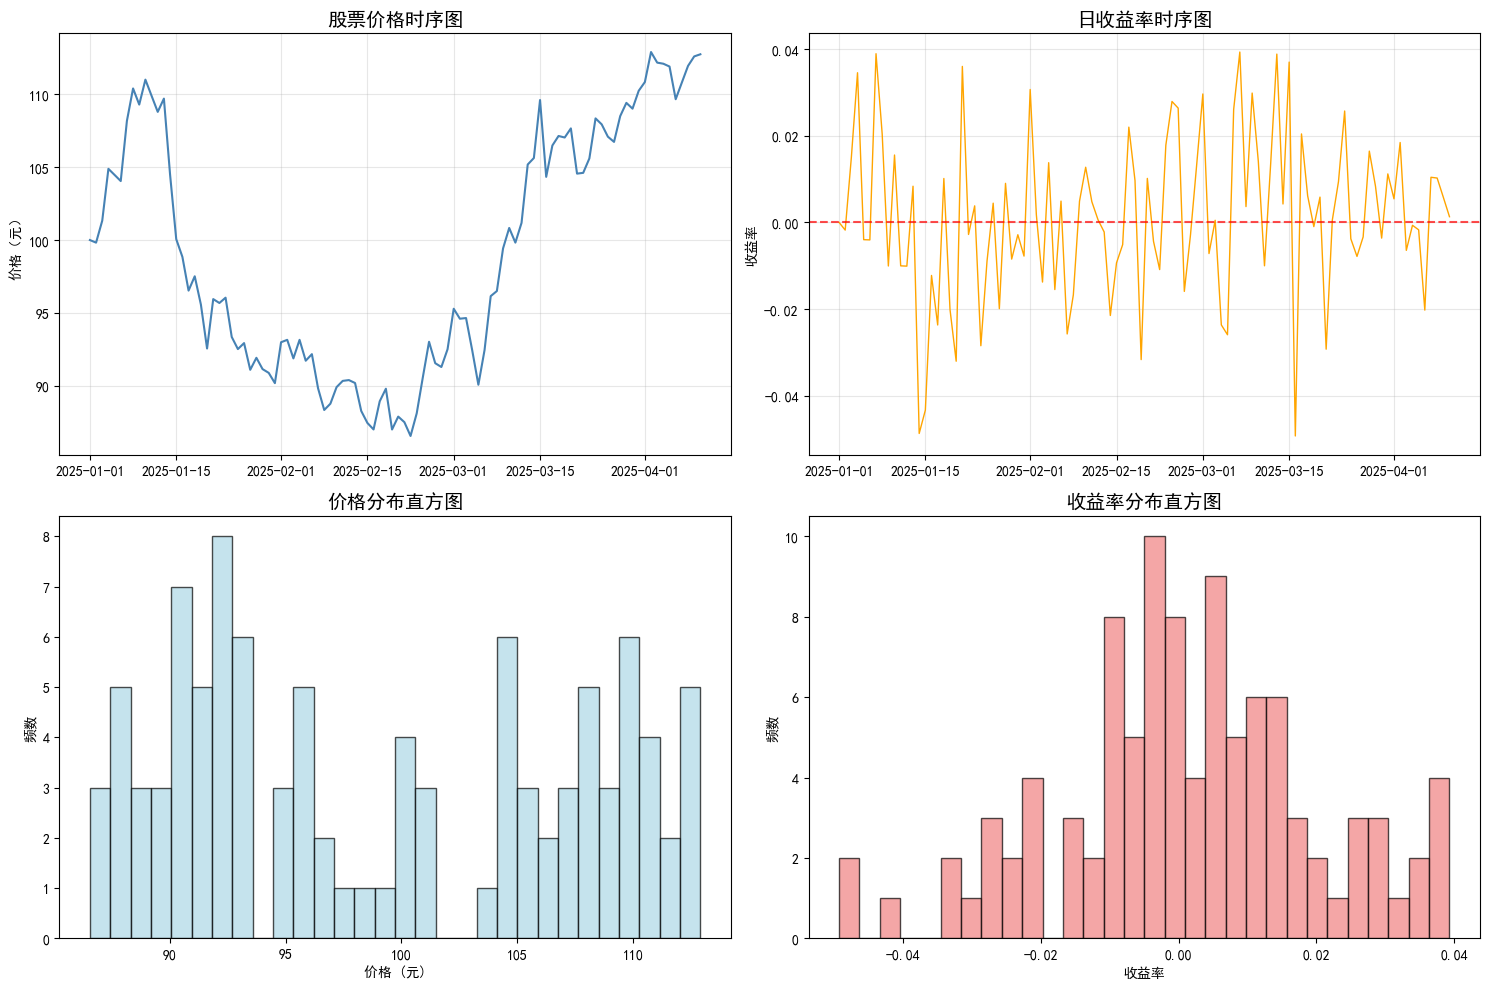

年化波动率: 30.02%
最大回撤: -22.04%
收益率偏度: -0.202
收益率峰度: 0.184


In [89]:
print("\n2.数据探索与可视化")
print('-'*30)

# 创建综合图标
fig, axes = plt.subplots(2, 2, figsize=(15,10))

# 价格时序图
axes[0,0].plot(stock_data.index,stock_data['price'],color='steelblue',linewidth=1.5)
axes[0,0].set_title('股票价格时序图',fontsize=14,fontweight='bold')
axes[0,0].set_ylabel('价格（元）')
axes[0,0].grid(True, alpha=0.3)

# 收益率时序图
axes[0,1].plot(stock_data.index,stock_data['returns'], color='orange',linewidth=1)
axes[0,1].axhline(y=0, color='red', linestyle='--', alpha=0.7)
axes[0,1].set_title('日收益率时序图',fontsize=14,fontweight='bold')
axes[0,1].set_ylabel('收益率')
axes[0,1].grid(True,alpha=0.3)

# 价格分布直方图
axes[1,0].hist(stock_data['price'],bins=30,color='lightblue',alpha=0.7,edgecolor='black')
axes[1,0].set_title('价格分布直方图', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('价格 (元)')
axes[1,0].set_ylabel('频数')

# 收益率分布直方图
axes[1,1].hist(stock_data['returns'], bins=30, color='lightcoral', alpha=0.7, edgecolor='black')
axes[1,1].set_title('收益率分布直方图', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('收益率')
axes[1,1].set_ylabel('频数')

plt.tight_layout()
plt.show()

# 计算一些描述性统计量
price_volatility = stock_data['returns'].std() * np.sqrt(252)  # 年化波动率
max_drawdown = ((stock_data['price']/stock_data['price'].cummax()) - 1).min()  # 最大回撤

print(f"年化波动率: {price_volatility:.2%}")
print(f"最大回撤: {max_drawdown:.2%}")
print(f"收益率偏度: {stock_data['returns'].skew():.3f}")
print(f"收益率峰度: {stock_data['returns'].kurtosis():.3f}")


第三步：平稳性检验(ADF)


3.平稳性检验
------------------------------

原始价格序列 ADF检测结果:
ADF统计量:-0.524057
p值:0.887236
临界值:
   1%:-3.498
   5%:-2.891
   10%:-2.583
结论: 原始价格序列是非平稳的 (p值 = 0.887236 > 0.05)

收益率序列 ADF检测结果:
ADF统计量:-9.462185
p值:0.000000
临界值:
   1%:-3.498
   5%:-2.891
   10%:-2.583
结论: 收益率序列是平稳的 (p值 = 0.000000 < 0.05)

价格一阶差分序列 ADF检测结果:
ADF统计量:-9.486014
p值:0.000000
临界值:
   1%:-3.499
   5%:-2.892
   10%:-2.583
结论: 价格一阶差分序列是平稳的 (p值 = 0.000000 < 0.05)


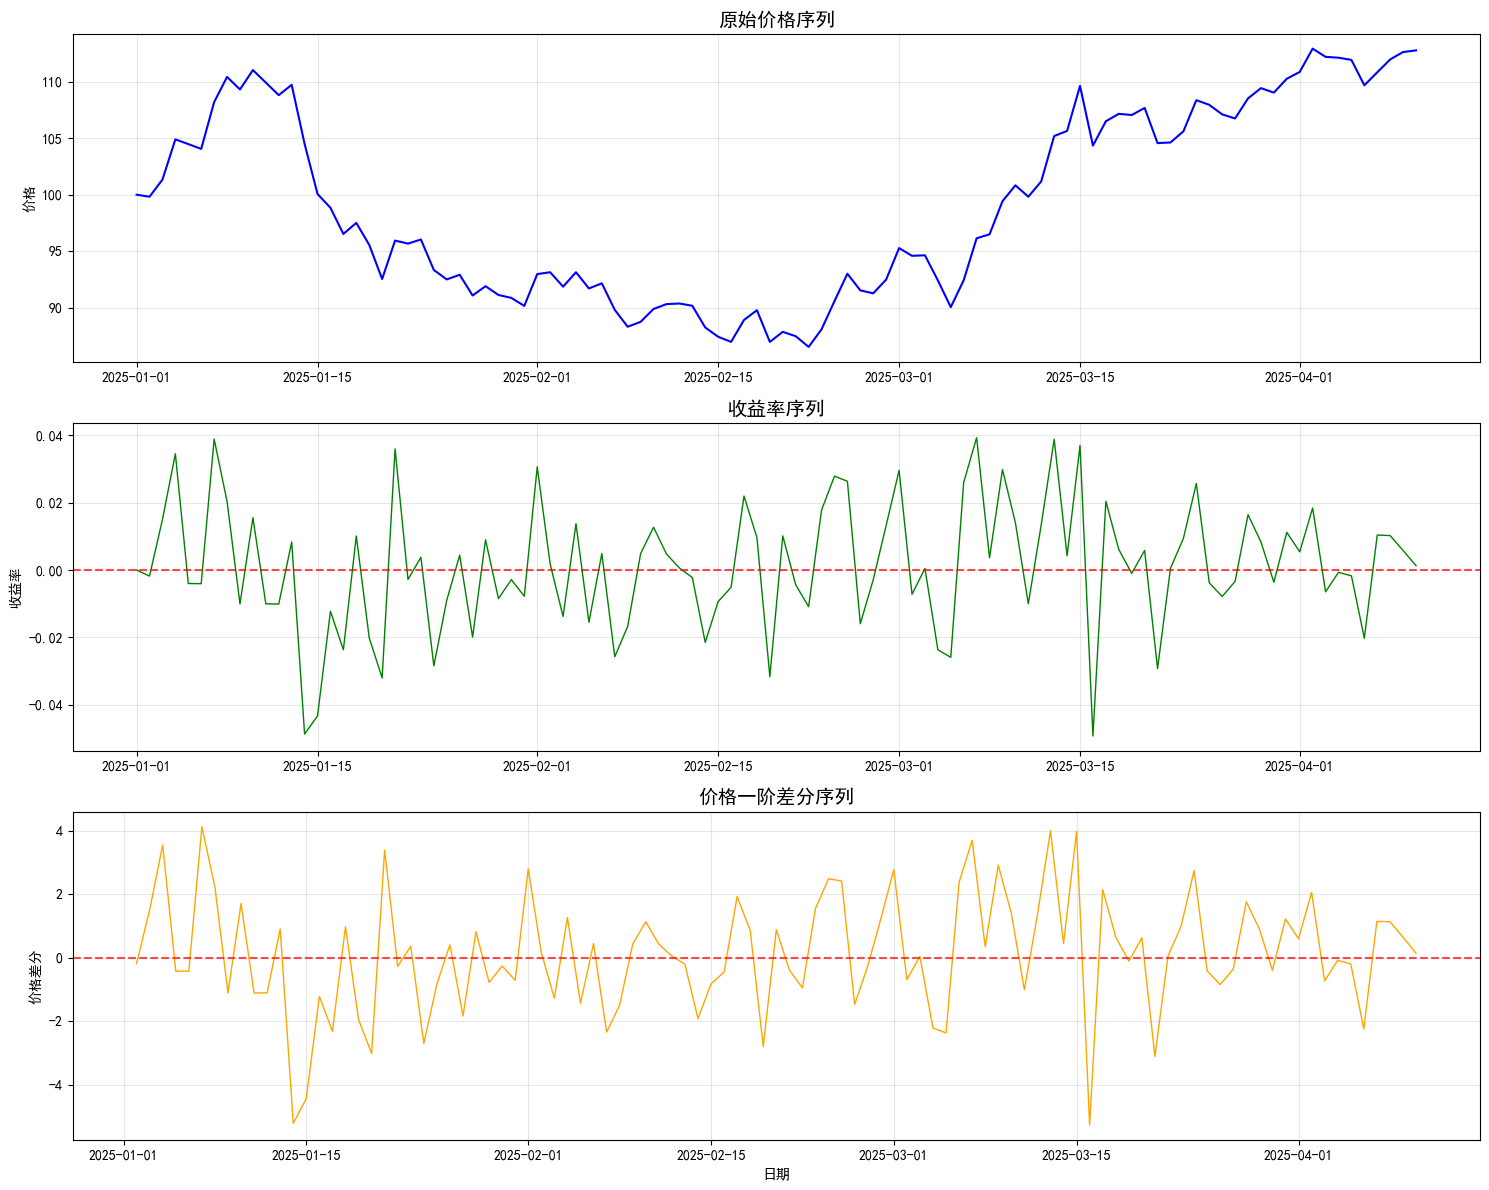

In [90]:
print('\n3.平稳性检验')
print('-'*30)

def detailed_adf_test(timeseries,title='时间序列'):
    """
    详细的ADF平稳性检验
    """
    result = adfuller(timeseries.dropna())  #ADF检验 = Augmented Dickey-Fuller Test（增广迪基-富勒检验）

    print(f'\n{title} ADF检测结果:')
    print(f'ADF统计量:{result[0]:.6f}')  #result[0]:ADF统计量(越负越平稳)
    print(f'p值:{result[1]:.6f}')  #result[1]  p值
    print('临界值:')
    for key,value in  result[4].items():
        print(f'   {key}:{value:.3f}')

    if result[1] <= 0.05:
        print(f'结论: {title}是平稳的 (p值 = {result[1]:.6f} < 0.05)')
        return True
    else:
        print(f'结论: {title}是非平稳的 (p值 = {result[1]:.6f} > 0.05)')
        return False

# 检验原始价格序列
price_stationary = detailed_adf_test(stock_data['price'], '原始价格序列')
# 检验收益率序列
returns_stationary = detailed_adf_test(stock_data['returns'], '收益率序列')

# 如果价格序列平稳，则进行差分
if not price_stationary:
    stock_data['price_diff'] = stock_data['price'].diff()
    diff_stationary = detailed_adf_test(stock_data['price_diff'], '价格一阶差分序列')


fig, axes = plt.subplots(3,1,figsize=(15,12))

# 原始价格
axes[0].plot(stock_data['price'], color='blue', linewidth=1.5)
axes[0].set_title('原始价格序列',fontsize=14,fontweight='bold')
axes[0].set_ylabel('价格')
axes[0].grid(True, alpha=0.3)

#收益率
axes[1].plot(stock_data['returns'], color='green', linewidth=1)
axes[1].axhline(y=0, linestyle='--', color='red', alpha=0.7)
axes[1].set_title('收益率序列',fontsize=14,fontweight='bold')
axes[1].set_ylabel('收益率')
axes[1].grid(True, alpha=0.3)

# 价格差分
axes[2].plot(stock_data['price_diff'], color='orange', linewidth=1)
axes[2].axhline(y=0, color='red', linestyle='--', alpha=0.7)
axes[2].set_title('价格一阶差分序列', fontsize=14, fontweight='bold')
axes[2].set_ylabel('价格差分')
axes[2].set_xlabel('日期')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

第四步：ACF和PACF分析


4. ACF和PACF分析
------------------------------


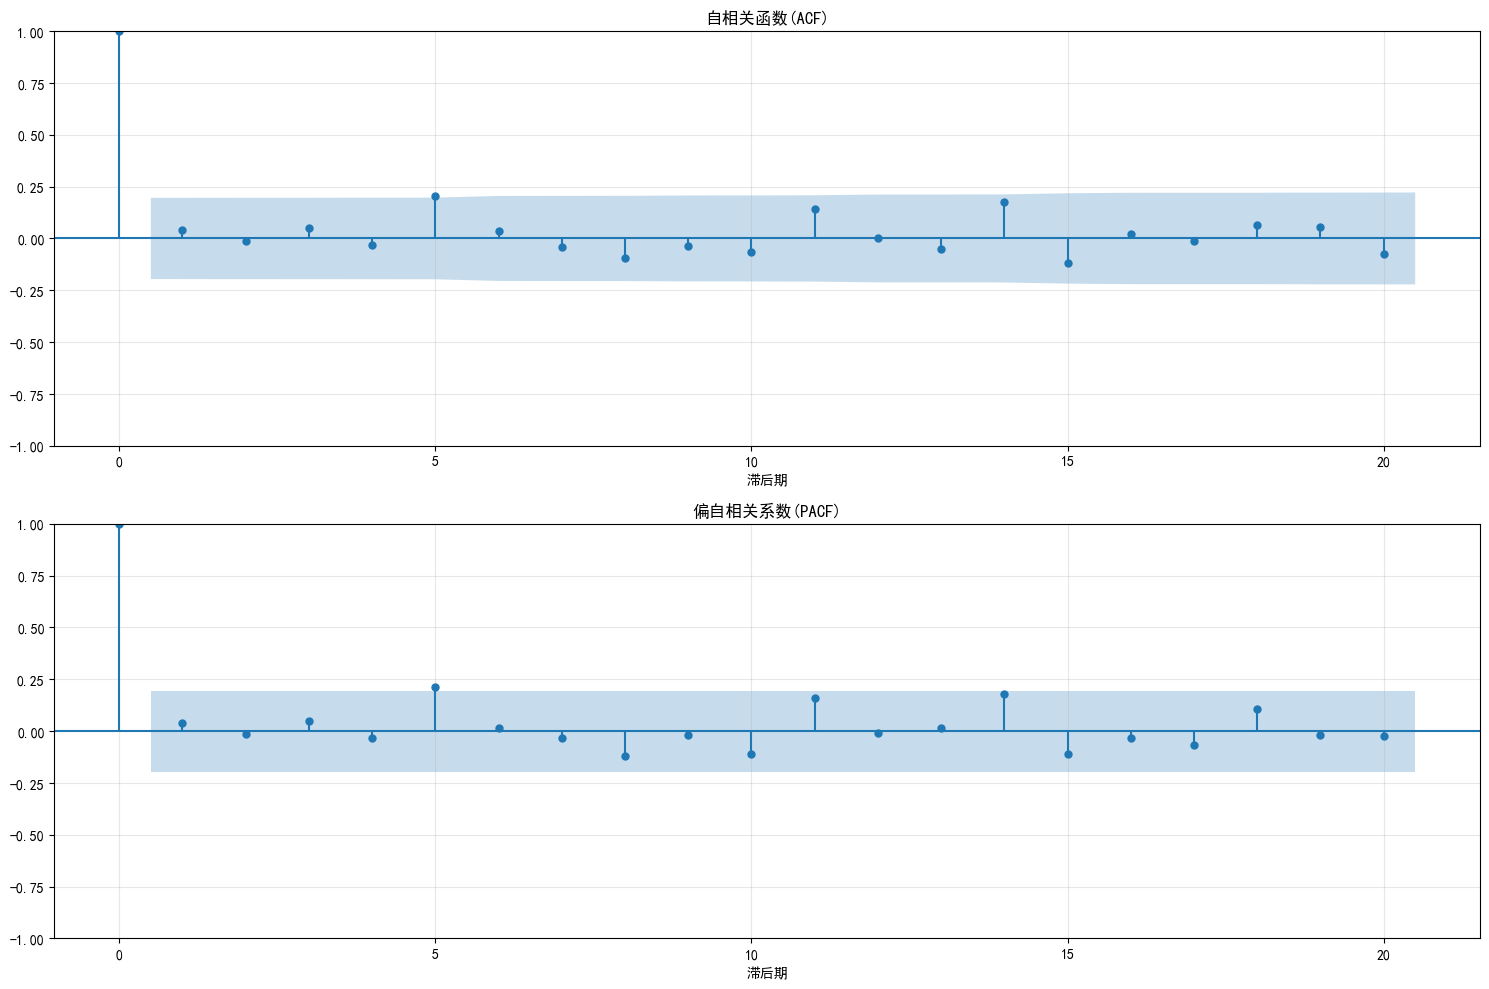

显著的ACF滞后阶数: [5]
显著的PACF滞后阶数: [5]
建议的AR阶数 (p): 3
建议的MA阶数 (q): 3


In [91]:
print("\n4. ACF和PACF分析")
print("-" * 30)

# 选择平稳序列进行分析
analysis_data = stock_data['returns'].dropna()

# 绘制ACF和PACF图
fig, axes = plt.subplots(2,1, figsize=(15,10))

# ACF图
plot_acf(analysis_data,ax=axes[0],lags=20,title='自相关函数(ACF)')
axes[0].set_xlabel('滞后期')
axes[0].grid(True, alpha=0.3)

# PACF图
plot_pacf(analysis_data, ax=axes[1], lags=20, title='偏自相关系数(PACF)')
axes[1].set_xlabel('滞后期')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 分析ACF和PACF的截尾特征
def analyze_acf_pacf(data, max_lags=10):
    """
    分析ACF和PACF的截尾特征,建议模型参数
    """
    from statsmodels.tsa.stattools import acf, pacf

    # 计算ACF和PACF值
    acf_value = acf(data,nlags=max_lags,fft=False)
    pacf_value = pacf(data,nlags=max_lags)

    # 95%置信区间
    n = len(data)
    confidence_interval = 1.96 / np.sqrt(n)

    # 找出显著的滞后阶数
    significant_acf = [i for i in range(1,len(acf_value)) if abs(acf_value[i])>confidence_interval]
    significant_pacf = [i for i in range(1,len(pacf_value)) if abs(pacf_value[i])>confidence_interval]

    print(f"显著的ACF滞后阶数: {significant_acf[:5]}")  # 只显示前5个
    print(f"显著的PACF滞后阶数: {significant_pacf[:5]}")

    # 建议参数
    if len(significant_acf) > 0:
        suggested_q = min(3, max(significant_acf[:3]))
    else:
        suggested_q = 0

    if len(significant_pacf) > 0:
        suggested_p = min(3, max(significant_pacf[:3]))
    else:
        suggested_p = 0

    print(f"建议的AR阶数 (p): {suggested_p}")
    print(f"建议的MA阶数 (q): {suggested_q}")
    
    return suggested_p, suggested_q

suggested_p, suggested_q = analyze_acf_pacf(analysis_data)

第五步：ARIMA模型识别与选择

In [92]:
print('\n5.ARIMA模型识别与选择')
print('-'*30)

# 网格化搜索最优ARIMA参数
def grid_search_arima(data,max_p=3,max_d=2,max_q=3):
    # 限制范围：避免过拟合（高阶模型参数多，拟合噪声）
    """
    网格搜索最优ARIMA参数
    """
    import itertools

    # 生成所有可能的参数组合
    p_values = range(0,max_p+1)
    d_values = range(0, max_d + 1)
    q_values = range(0, max_q + 1)

    best_aic = float('inf')  #最优模型的AIC最小
    best_params = None
    results_list = []

    print("开始网格搜索最优ARIMA参数...")
    print("参数组合评估:")

    for p,d,q in itertools.product(p_values,d_values,q_values):
        # itertools.product 生成笛卡尔积
        try:
            model = ARIMA(data, order=(p,d,q))
            fitted_model = model.fit()

            aic = fitted_model.aic
            bic = fitted_model.bic

            results_list.append({
                'params':(p,q,d),
                'AIC':aic,
                'BIC':bic
            })

            print(f"ARIMA({p},{d},{q}) - AIC: {aic:.2f}, BIC: {bic:.2f}")

            if aic < best_aic:
                best_aic = aic
                best_params = (p,d,q)

        except Exception as e:
            print(f"ARIMA({p},{d},{q}) - 拟合失败: {str(e)[:50]}")
            continue


    # 转换为DataFrame便于分析
    results_df = pd.DataFrame(results_list)

    print(f"\n最优参数: ARIMA{best_params}")
    print(f"最佳AIC值: {best_aic:.2f}")
    
    return best_params, results_df

best_params, search_result = grid_search_arima(stock_data['returns'].dropna(), max_p=3, max_d=1, max_q=3)

# 显示前十个最佳模型
print('\n前十个最佳模型(按AIC排序)')
top_models = search_result.nsmallest(10,'AIC')
for idx, row in top_models.iterrows():
    print(f"ARIMA{row['params']} - AIC: {row['AIC']:.2f}, BIC: {row['BIC']:.2f}")


5.ARIMA模型识别与选择
------------------------------
开始网格搜索最优ARIMA参数...
参数组合评估:
ARIMA(0,0,0) - AIC: -506.82, BIC: -501.61
ARIMA(0,0,1) - AIC: -504.98, BIC: -497.17
ARIMA(0,0,2) - AIC: -503.01, BIC: -492.59
ARIMA(0,0,3) - AIC: -501.40, BIC: -488.38
ARIMA(0,1,0) - AIC: -438.14, BIC: -435.55
ARIMA(0,1,1) - AIC: -496.72, BIC: -491.53
ARIMA(0,1,2) - AIC: -494.80, BIC: -487.01
ARIMA(0,1,3) - AIC: -492.88, BIC: -482.50
ARIMA(1,0,0) - AIC: -504.98, BIC: -497.16
ARIMA(1,0,1) - AIC: -504.59, BIC: -494.17
ARIMA(1,0,2) - AIC: -501.01, BIC: -487.98
ARIMA(1,0,3) - AIC: -500.90, BIC: -485.27
ARIMA(1,1,0) - AIC: -460.95, BIC: -455.76
ARIMA(1,1,1) - AIC: -494.79, BIC: -487.01
ARIMA(1,1,2) - AIC: -494.08, BIC: -483.70
ARIMA(1,1,3) - AIC: -492.43, BIC: -479.46
ARIMA(2,0,0) - AIC: -503.00, BIC: -492.58
ARIMA(2,0,1) - AIC: -501.00, BIC: -487.97
ARIMA(2,0,2) - AIC: -500.72, BIC: -485.09
ARIMA(2,0,3) - AIC: -499.15, BIC: -480.92
ARIMA(2,1,0) - AIC: -472.78, BIC: -464.99
ARIMA(2,1,1) - AIC: -492.86, BIC: -482.48
AR

第六步：模型拟合与参数估计

In [93]:
print("\n6. 模型拟合与参数估计")
print("-" * 30)

# 使用最优参数拟合ARIMA模型
optional_model = ARIMA(stock_data['returns'].dropna(),order=best_params)
fitted_model = optional_model.fit()

# 显示模型摘要
print("最优ARIMA模型摘要:")
print(fitted_model.summary())

# 提取模型参数
params = fitted_model.params
# 拟合后，fitted_model 包含各种属性和方法
# fitted_model.params           ← 模型估计的参数值
# fitted_model.aic              ← AIC信息准则
# fitted_model.bic              ← BIC信息准则
# fitted_model.resid            ← 残差序列
for param_name, param_value in params.items():
    print(f'{param_name}:{param_value:.6f}')



6. 模型拟合与参数估计
------------------------------
最优ARIMA模型摘要:
                               SARIMAX Results                                
Dep. Variable:                returns   No. Observations:                  100
Model:                          ARIMA   Log Likelihood                 255.410
Date:                Sat, 18 Jul 2026   AIC                           -506.820
Time:                        16:11:50   BIC                           -501.610
Sample:                    01-01-2025   HQIC                          -504.711
                         - 04-10-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0012      0.002      0.629      0.529      -0.003       0.005
sigma2         0.0004   4.92e-05      7.199      0.000       0.000       

第七步：模型诊断


7. 模型诊断
------------------------------
残差统计信息
残差均值：0.00000501
残差标准差：0.01891098
残差偏度：-0.20215066
残差峰度：0.18350936


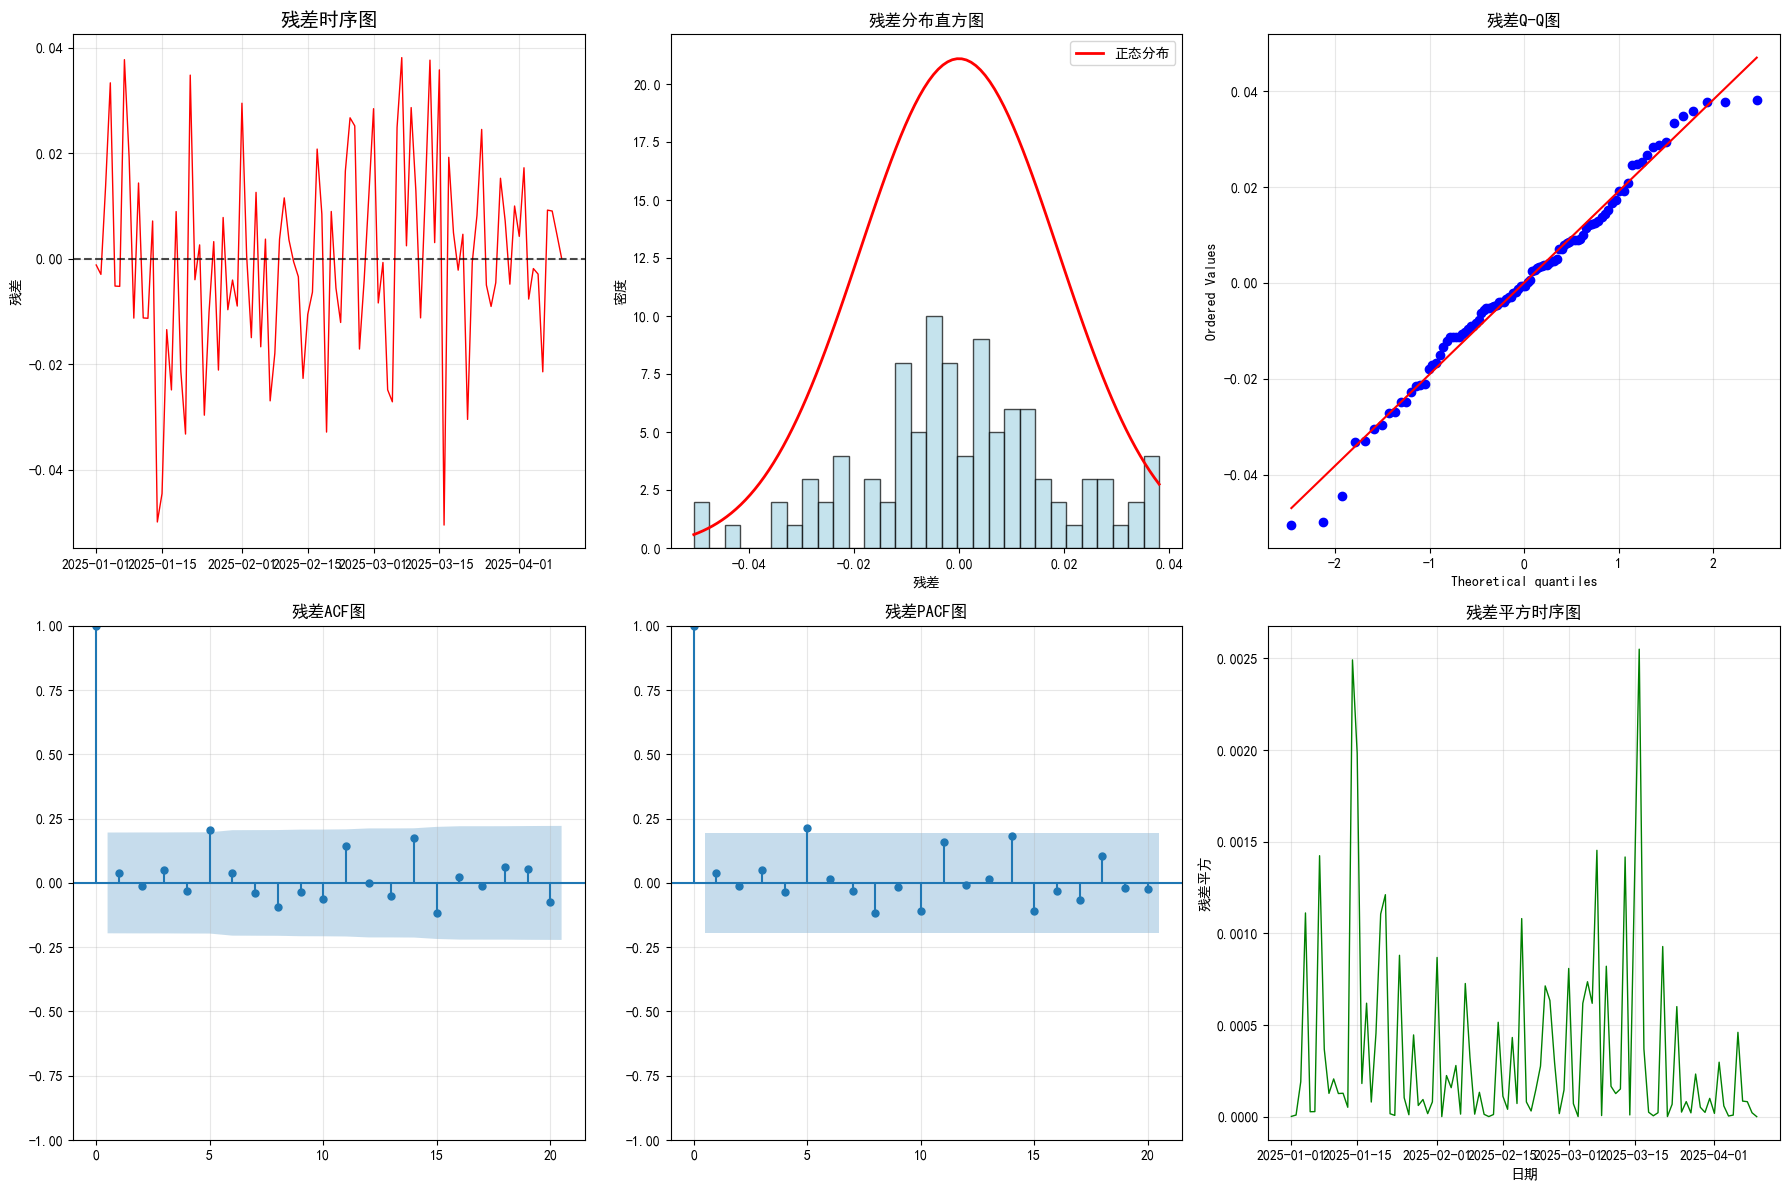


Ljung_Box检验结果(残差自相关):
     lb_stat  lb_pvalue
1   0.165270   0.684351
2   0.180807   0.913562
3   0.426769   0.934659
4   0.525341   0.970988
5   5.107007   0.402961
6   5.261138   0.510783
7   5.435027   0.607032
8   6.412034   0.601180
9   6.559405   0.682885
10  7.028360   0.722765
结论：残差不存在显著自相关性(模型充分)

Jarque-Bera正态性检验:
统计量: 0.7159
p值: 0.699117
结论: 残差服从正态分布


In [94]:
print("\n7. 模型诊断")
print("-" * 30)

# 获取残差
residuals = fitted_model.resid

# 残差基本统计
print('残差统计信息')
print(f"残差均值：{residuals.mean():.8f}")
print(f"残差标准差：{residuals.std():.8f}")
print(f"残差偏度：{residuals.skew():.8f}")
print(f"残差峰度：{residuals.kurtosis():.8f}")

fig,axes = plt.subplots(2,3,figsize=(18,12))

# 残差时序图
axes[0,0].plot(residuals.index, residuals, color='red', linewidth=1)
axes[0,0].axhline(y=0, color='black', linestyle='--', alpha=0.7)
axes[0,0].set_title('残差时序图', fontsize=14, fontweight='bold')
axes[0,0].set_ylabel('残差')
axes[0,0].grid(True, alpha=0.3)

# 残差直方图
axes[0,1].hist(residuals,bins=30,color='lightblue',alpha=0.7,edgecolor='black')
# 叠加正态分布曲线
x = np.linspace(residuals.min(),residuals.max(),100)
# 正态分布概率函数公式
normal_curve = (1 / np.sqrt(2*np.pi*residuals.var())) * np.exp(-0.5 * ((x-residuals.mean())/residuals.std())**2)
axes[0,1].plot(x, normal_curve, 'r-', linewidth=2,label='正态分布')
axes[0,1].set_title('残差分布直方图', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('残差')
axes[0,1].set_ylabel('密度')
axes[0,1].legend()

# 残差Q-Q图
from scipy import stats
stats.probplot(residuals, dist='norm', plot=axes[0,2])
axes[0,2].set_title('残差Q-Q图', fontsize=12, fontweight='bold')
axes[0,2].grid(True, alpha=0.3)

# 残差ACF图
plot_acf(residuals, ax=axes[1,0], lags=20, title='残差ACF图')
axes[1,0].grid(True, alpha=0.3)

# 残差PACF图
plot_pacf(residuals, ax=axes[1,1], lags=20, title='残差PACF图')
axes[1,1].grid(True, alpha=0.3)

# 残差平方的时序图
axes[1,2].plot(residuals.index, residuals**2, color='green', linewidth=1)
axes[1,2].set_title('残差平方时序图', fontsize=12, fontweight='bold')
axes[1,2].set_ylabel('残差平方')
axes[1,2].set_xlabel('日期')
axes[1,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Ljung_Box检验（残差自相关检验）
lb_best = acorr_ljungbox(residuals, lags=10, return_df=True)
print('\nLjung_Box检验结果(残差自相关):')
print(lb_best)

if all(lb_best['lb_pvalue'] > 0.05):
    print('结论：残差不存在显著自相关性(模型充分)')
else:
    print("结论: 残差存在自相关性（模型可能不充分）")


# Jarque-Bera正态性检验
from scipy.stats import jarque_bera
jb_stat, jb_pvalue = jarque_bera(residuals)
print(f"\nJarque-Bera正态性检验:")
print(f"统计量: {jb_stat:.4f}")
print(f"p值: {jb_pvalue:.6f}")

if jb_pvalue > 0.05:
    print("结论: 残差服从正态分布")
else:
    print("结论: 残差不服从正态分布")

8.模型预测


8. 模型预测
------------------------------


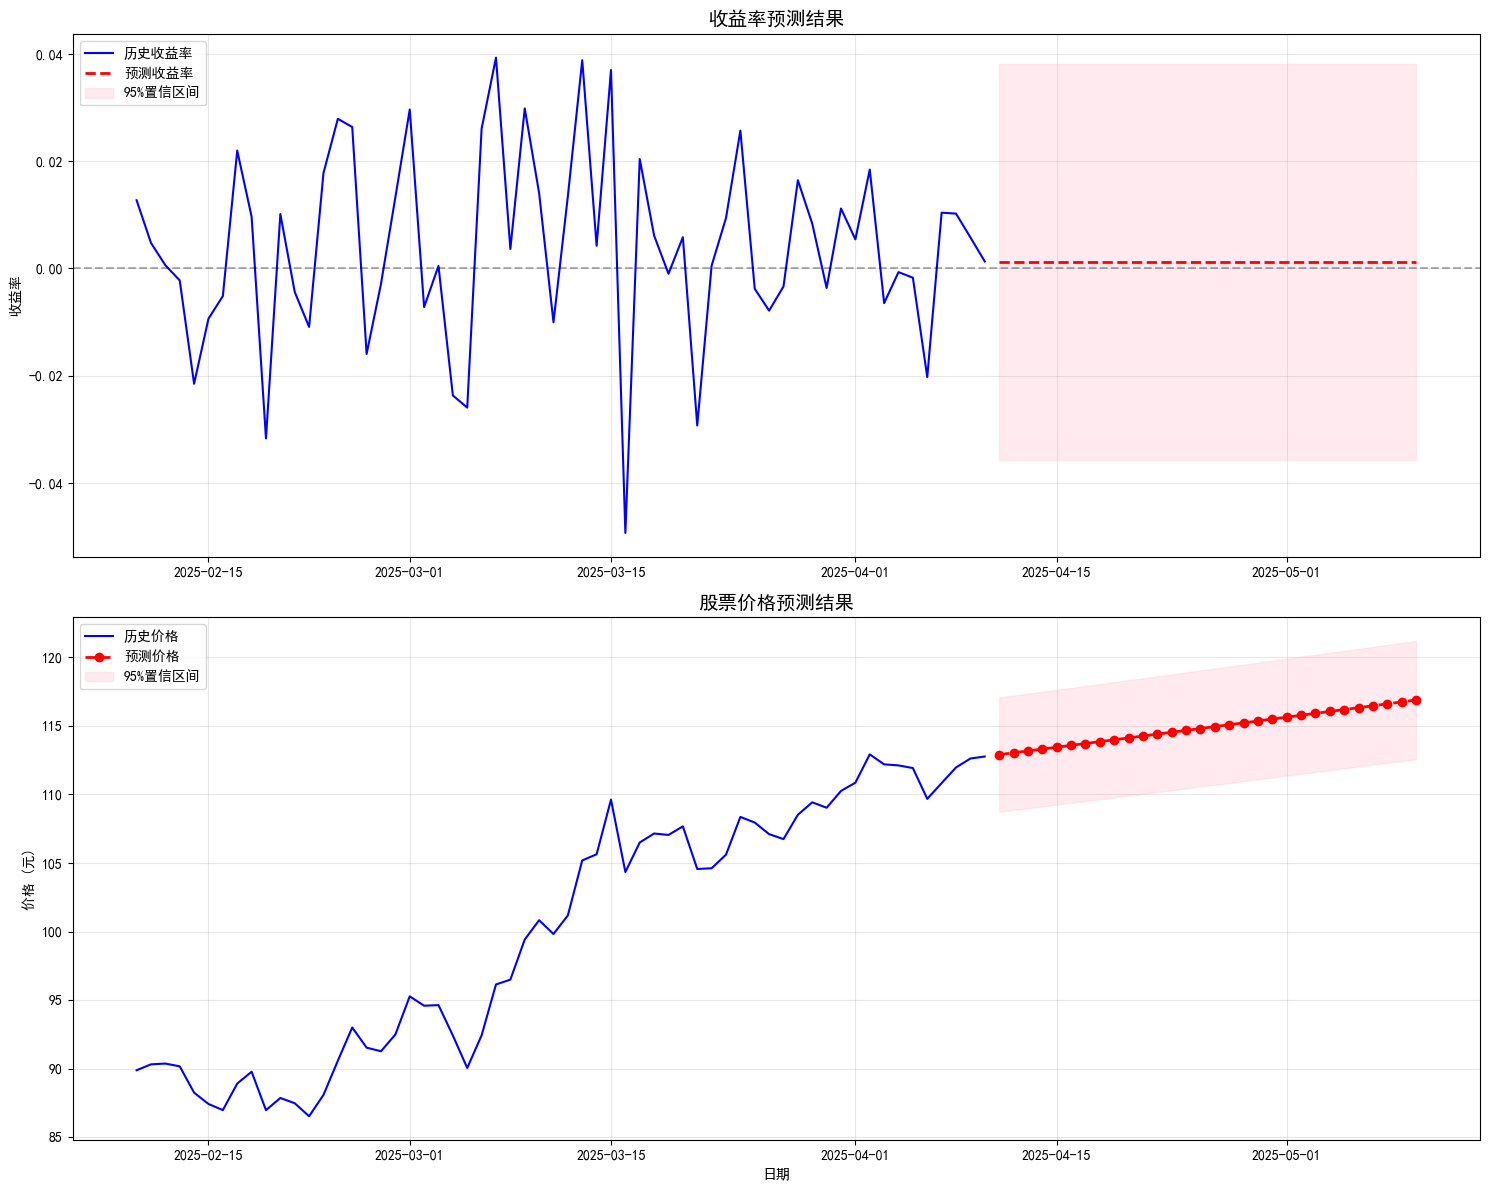

未来10天预测结果:
                   日期   预测收益率   收益率下限   收益率上限      预测价格      价格下限      价格上限
2025-04-11 2025-04-11  0.0012 -0.0357  0.0381  112.8904  108.7309  117.0498
2025-04-12 2025-04-12  0.0012 -0.0357  0.0381  113.0253  108.8609  117.1897
2025-04-13 2025-04-13  0.0012 -0.0357  0.0381  113.1605  108.9911  117.3298
2025-04-14 2025-04-14  0.0012 -0.0357  0.0381  113.2957  109.1214  117.4701
2025-04-15 2025-04-15  0.0012 -0.0357  0.0381  113.4312  109.2518  117.6105
2025-04-16 2025-04-16  0.0012 -0.0357  0.0381  113.5668  109.3825  117.7511
2025-04-17 2025-04-17  0.0012 -0.0357  0.0381  113.7026  109.5132  117.8919
2025-04-18 2025-04-18  0.0012 -0.0357  0.0381  113.8385  109.6441  118.0329
2025-04-19 2025-04-19  0.0012 -0.0357  0.0381  113.9746  109.7752  118.1740
2025-04-20 2025-04-20  0.0012 -0.0357  0.0381  114.1109  109.9065  118.3152
------------------------------


In [95]:
print("\n8. 模型预测")
print("-" * 30)

# 预测未来30天的收益率
forecast_steps = 30
forecast = fitted_model.forecast(steps=forecast_steps)   # 点预测
forecast_ci = fitted_model.get_forecast(steps=forecast_steps).conf_int()   # 预测置信区间 

# 创建预测日期
last_date = stock_data.index[-1]
forecast_dates = pd.date_range(start=last_date + timedelta(days=1), periods=forecast_steps, freq='D')

# 将收益率预测转换为价格预测
last_price = stock_data['price'].iloc[-1]
predicted_prices = [last_price]

for return_forecast in forecast:
    next_price = predicted_prices[-1] * (1 + return_forecast)
    predicted_prices.append(next_price)

predicted_prices = predicted_prices[1:]   # 移除初始值

# 计算价格预测的置信区间
price_ci_lower = []
price_ci_upper = []
current_price = last_price

for i in range(forecast_steps):
    lower_return = forecast_ci.iloc[i,0]
    upper_return = forecast_ci.iloc[i,1]

    # 简化的置信区间计算（实际应考虑累积效应）
    lower_price = current_price * (1+lower_return)
    upper_price = current_price * (1+upper_return)

    price_ci_lower.append(lower_price)
    price_ci_upper.append(upper_price)

    current_price = predicted_prices[i]  # 更新当前价格

# 预测结果可视化
fig,axes = plt.subplots(2,1,figsize=(15,12))

# 收益率预测
axes[0].plot(stock_data.index[-60:], stock_data['returns'][-60:], label='历史收益率', color='blue', linewidth=1.5)
axes[0].plot(forecast_dates, forecast, label='预测收益率', color='red', linestyle='--', linewidth=2)
axes[0].fill_between(forecast_dates, forecast_ci.iloc[:,0], forecast_ci.iloc[:,1], color='pink', alpha=0.3, label='95%置信区间')
axes[0].axhline(y=0, color='black', linestyle='--', alpha=0.3)
axes[0].set_title('收益率预测结果', fontsize=14, fontweight='bold')
axes[0].set_ylabel('收益率')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 价格预测
axes[1].plot(stock_data.index[-60:], stock_data['price'][-60:], 
            label='历史价格', color='blue', linewidth=1.5)
axes[1].plot(forecast_dates, predicted_prices,
            label='预测价格', color='red', linestyle='--', linewidth=2, marker='o')
axes[1].fill_between(forecast_dates, price_ci_lower, price_ci_upper,
                    color='pink', alpha=0.3, label='95%置信区间')
axes[1].set_title('股票价格预测结果', fontsize=14, fontweight='bold')
axes[1].set_ylabel('价格 (元)')
axes[1].set_xlabel('日期')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 预测结果表格
forecast_df = pd.DataFrame({
    '日期': forecast_dates,
    '预测收益率': forecast,
    '收益率下限': forecast_ci.iloc[:, 0],
    '收益率上限': forecast_ci.iloc[:, 1],
    '预测价格': predicted_prices,
    '价格下限': price_ci_lower,
    '价格上限': price_ci_upper
})

print("未来10天预测结果:")
print(forecast_df.head(10).round(4))
print("-" * 30)

第九步：模型评估


9. 模型评估
------------------------------
训练集大小: 80
测试集大小: 20

收益率预测精度评估:
MAE (平均绝对误差): 0.008442
RMSE (均方根误差): 0.010749
MAPE (平均绝对百分比误差): 99.30%
方向预测准确率: 60.00%


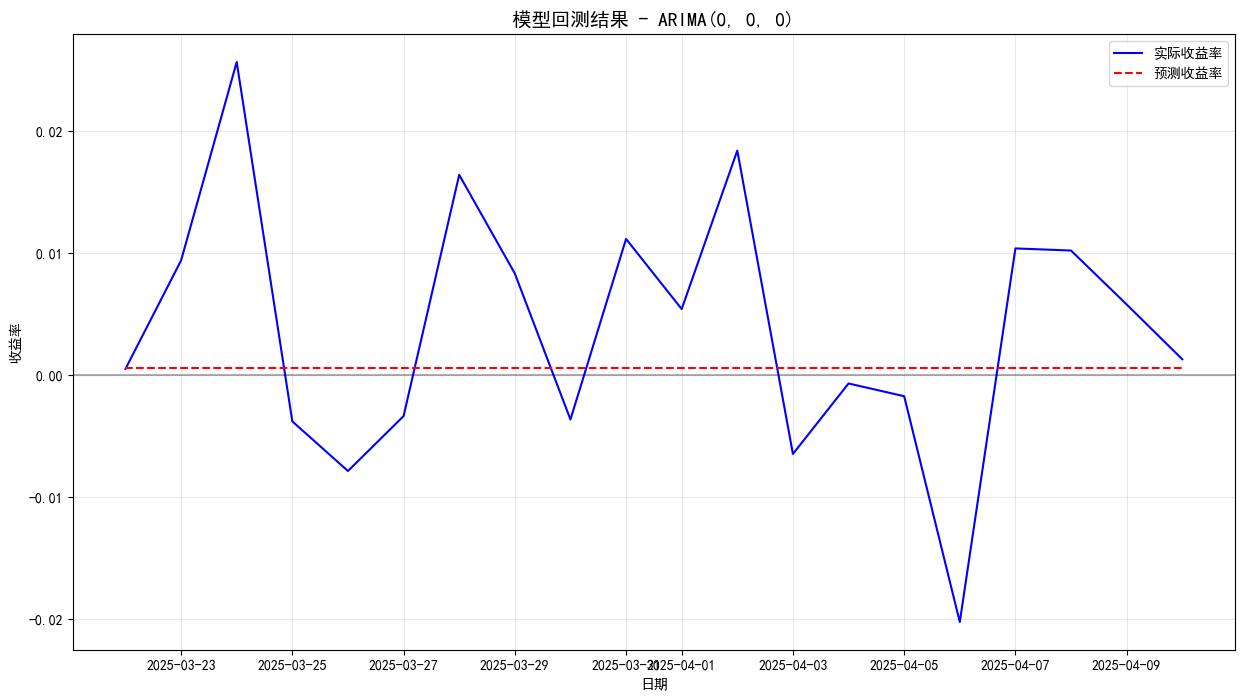

In [96]:
print("\n9. 模型评估")
print("-" * 30)

# 分割数据进行回测评估
split_ratio = 0.8
split_point = int(len(stock_data) * split_ratio)
train_data = stock_data['returns'][:split_point]
test_data = stock_data['returns'][split_point:]

print(f"训练集大小: {len(train_data)}")
print(f"测试集大小: {len(test_data)}")

# 重新训练模型
train_model = ARIMA(train_data,order=best_params)
train_fitted = train_model.fit()

# 预测测试期
test_forecast = train_fitted.forecast(steps=len(test_data))

# 计算评估指标
mae = mean_absolute_error(test_data, test_forecast)
rmse = np.sqrt(mean_squared_error(test_data, test_forecast))
mape = np.mean(np.abs((test_data - test_forecast) / test_data)) * 100

print(f"\n收益率预测精度评估:")
print(f"MAE (平均绝对误差): {mae:.6f}")
print(f"RMSE (均方根误差): {rmse:.6f}")
print(f"MAPE (平均绝对百分比误差): {mape:.2f}%")

# 方向准确率(预测涨跌方向的准确率)
actual_direction = np.sign(test_data)
predicted_direction = np.sign(test_forecast)
direction_accuracy = np.mean(actual_direction == predicted_direction)
print(f"方向预测准确率: {direction_accuracy:.2%}")

# 可视化回测结果
plt.figure(figsize=(15, 8))
plt.plot(test_data.index, test_data, label='实际收益率', color='blue', linewidth=1.5)
plt.plot(test_data.index, test_forecast, label='预测收益率', color='red', linestyle='--', linewidth=1.5)
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.title(f'模型回测结果 - ARIMA{best_params}', fontsize=14, fontweight='bold')
plt.xlabel('日期')
plt.ylabel('收益率')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

第十步：总结与建议

In [97]:
print("\n10. 结果总结与投资建议")
print("-" * 30)

# 模型总结
print(f"最优ARIMA模型: ARIMA{best_params}")
print(f"模型AIC值: {fitted_model.aic:.2f}")
print(f"模型BIC值: {fitted_model.bic:.2f}")

# 预测总结
avg_predicted_return = forecast.mean()
predicted_volatility = forecast.std()
price_change_expected = (predicted_prices[-1] / last_price - 1) * 100

print(f"\n预测总结（未来30天）:")
print(f"平均日收益率预期: {avg_predicted_return:.4f} ({avg_predicted_return*100:.2f}%)")
print(f"预测波动率: {predicted_volatility:.4f}")
print(f"期末价格预期: {predicted_prices[-1]:.2f} 元")
print(f"总收益率预期: {price_change_expected:.2f}%")
print(f"年化收益率预期: {avg_predicted_return * 252 * 100:.2f}%")

# 风险评估
var_95 = np.percentile(forecast, 5)  # 95% VaR
print(f"\n风险评估:")
print(f"日VaR (95%): {var_95:.4f} ({var_95*100:.2f}%)")
print(f"最大预期损失 (30天): {(last_price * (1 + var_95) - last_price):.2f} 元")

# 投资建议
if avg_predicted_return > 0.001:  # 日收益率大于0.1%
    recommendation = "买入"
    reason = "模型预测未来收益为正，建议适量买入"
elif avg_predicted_return < -0.001:  # 日收益率小于-0.1%
    recommendation = "卖出"
    reason = "模型预测未来收益为负，建议适量卖出"
else:
    recommendation = "持有"
    reason = "模型预测未来收益接近零，建议持有观望"

print(f"\n投资建议: {recommendation}")
print(f"建议理由: {reason}")
print(f"风险提示: 模型基于历史数据，实际结果可能存在差异，请谨慎投资")

# 保存结果
results_summary = {
    'model_type': f'ARIMA{best_params}',
    'model_aic': fitted_model.aic,
    'model_bic': fitted_model.bic,
    'mae': mae,
    'rmse': rmse,
    'mape': mape,
    'direction_accuracy': direction_accuracy,
    'expected_return_30d': price_change_expected,
    'recommendation': recommendation
}

print(f"\n模型性能总结:")
for key, value in results_summary.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")

print("\n" + "="*60)
print("                    案例一分析完成！")
print("="*60)


10. 结果总结与投资建议
------------------------------
最优ARIMA模型: ARIMA(0, 0, 0)
模型AIC值: -506.82
模型BIC值: -501.61

预测总结（未来30天）:
平均日收益率预期: 0.0012 (0.12%)
预测波动率: 0.0000
期末价格预期: 116.87 元
总收益率预期: 3.65%
年化收益率预期: 30.13%

风险评估:
日VaR (95%): 0.0012 (0.12%)
最大预期损失 (30天): 0.13 元

投资建议: 买入
建议理由: 模型预测未来收益为正，建议适量买入
风险提示: 模型基于历史数据，实际结果可能存在差异，请谨慎投资

模型性能总结:
model_type: ARIMA(0, 0, 0)
model_aic: -506.8199
model_bic: -501.6095
mae: 0.0084
rmse: 0.0107
mape: 99.3044
direction_accuracy: 0.6000
expected_return_30d: 3.6494
recommendation: 买入

                    案例一分析完成！
